<a href="https://colab.research.google.com/github/andinaufal120/kalimantan-frp-prediction/blob/main/playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-Based FRP Estimation in Kalimantan

## Preparation

### Notebook setup

In [1]:
# Import dependencies
from typing import Final
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set up Matplotlib graphical backend
%matplotlib inline

# Random state (seed) that will be used for this notebook.
SEED: Final[int] = 42

# Path of the dataset file.
PATH: Final[str] = "./Dataset_ML.csv"

# Directory to save artifacts
FIG_DIR: Final[str] = "./artifacts/figures/"

### Loading data into DataFrame

In [2]:
df = pd.read_csv(PATH)
row, col = df.shape
print(f"Loaded {row} rows, {col} cols.")

Loaded 59155 rows, 46 cols.


## Data Structure Overview

- Sample of five random rows
- Quick data info
- Numeric values summaries

In [3]:
df.sample(n=5, random_state=SEED)

,latitude,longitude,acq_date,acq_time,satellite,frp,ndvi,evi,ndvi_age_days,ndwi,...,hdasi,wffsp,diurnal_burn_potential,frp_log1p,dist_river_m,dist_road_m,pop_density,dist_settlement_m,forest_clearance_index,dist_settlement_osm_m
19592,-2.956348,112.847688,2023-09-25,553.0,N,3.68,0.8371,0.4122,11.0,0.166949,...,84.245592,9.768272,2.050073,1.543298,311.378754,6301.860855,0.074767,0.0,8.561753,13872.430191
25591,-1.693370,112.561315,2023-08-29,600.0,N,22.75,0.3169,0.2602,0.0,0.169195,...,73.800222,7.427479,1.782139,3.167583,1376.780571,309.539538,0.131053,0.0,17.230813,13606.339340
54489,-2.903281,114.856134,2023-09-27,1757.0,N,1.39,0.6224,0.4113,13.0,-0.035327,...,22.746127,5.868060,0.000000,0.871293,467.290837,2066.350423,0.336809,0.0,0.000000,5976.416154
39664,-1.714199,111.184465,2023-08-27,637.0,N,6.79,0.2493,0.2164,14.0,0.186272,...,35.864551,6.737016,0.817498,2.052841,723.566795,481.350604,0.229342,0.0,15.237049,1373.993047
8550,-2.732898,115.061578,2023-08-04,528.0,N,2.03,0.6397,0.3304,7.0,0.086936,...,89.357801,5.684845,2.217294,1.108563,1411.474010,3452.556553,0.227093,0.0,0.000000,25477.160884


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59155 entries, 0 to 59154
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   latitude                59155 non-null  float64
 1   longitude               59155 non-null  float64
 2   acq_date                59155 non-null  str    
 3   acq_time                59155 non-null  float64
 4   satellite               59155 non-null  str    
 5   frp                     59155 non-null  float64
 6   ndvi                    59155 non-null  float64
 7   evi                     59155 non-null  float64
 8   ndvi_age_days           59155 non-null  float64
 9   ndwi                    59155 non-null  float64
 10  lst_siang               59155 non-null  float64
 11  lst_malam               59155 non-null  float64
 12  land_cover_type         59155 non-null  float64
 13  peat_type_class         59155 non-null  float64
 14  ssrd                    59155 non-null  float64
 

In [5]:
df.describe()

,latitude,longitude,acq_time,frp,ndvi,evi,ndvi_age_days,ndwi,lst_siang,lst_malam,...,hdasi,wffsp,diurnal_burn_potential,frp_log1p,dist_river_m,dist_road_m,pop_density,dist_settlement_m,forest_clearance_index,dist_settlement_osm_m
count,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,...,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000
mean,-2.146653,113.386488,898.510811,7.882060,0.657475,0.424460,7.331570,0.173111,31.575420,22.934315,...,55.971998,4.375343,1.259527,1.831917,787.113202,1791.152419,0.511201,78.767644,14.351637,14024.005353
std,0.946354,1.806744,530.675029,10.808641,0.184339,0.145236,4.771615,0.146001,3.807111,1.676484,...,37.711300,4.160836,1.020394,0.780345,599.880738,2471.020082,1.110431,680.353205,15.711097,9999.684353
min,-4.042670,109.840189,449.000000,0.110000,0.036200,0.017700,0.000000,-0.376934,13.190000,11.650000,...,0.000000,0.000000,0.000000,0.131028,0.022153,0.002807,0.000000,0.000000,0.000000,0.000000
25%,-2.871719,111.687347,541.000000,2.640000,0.559600,0.323800,3.000000,0.075737,28.870000,22.110000,...,21.869342,1.960568,0.000000,1.291984,316.703998,335.882139,0.086752,0.000000,2.168044,6560.929131
50%,-2.367930,113.978159,611.000000,5.020000,0.709300,0.445200,7.000000,0.203173,31.150000,22.930000,...,51.620517,3.346356,1.242264,1.795087,668.401208,964.806349,0.171982,0.000000,9.779287,11769.549304
75%,-1.493119,114.929983,1713.000000,8.880000,0.799000,0.528100,12.000000,0.286831,33.710000,23.730000,...,83.220434,5.452409,2.008452,2.290513,1123.322664,2211.968112,0.403810,0.000000,21.058615,19386.738109
max,0.063212,116.560942,1817.000000,359.120000,0.978500,0.864200,15.000000,0.475309,49.170000,40.090000,...,167.108635,83.641958,4.160190,5.327731,3228.016916,29634.129307,49.616245,26500.000000,100.000000,50000.000000


### Dropping null rows

All columns except `latitude` has exactly one same null row.

In [6]:
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59155 entries, 0 to 59154
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   latitude                59155 non-null  float64
 1   longitude               59155 non-null  float64
 2   acq_date                59155 non-null  str    
 3   acq_time                59155 non-null  float64
 4   satellite               59155 non-null  str    
 5   frp                     59155 non-null  float64
 6   ndvi                    59155 non-null  float64
 7   evi                     59155 non-null  float64
 8   ndvi_age_days           59155 non-null  float64
 9   ndwi                    59155 non-null  float64
 10  lst_siang               59155 non-null  float64
 11  lst_malam               59155 non-null  float64
 12  land_cover_type         59155 non-null  float64
 13  peat_type_class         59155 non-null  float64
 14  ssrd                    59155 non-null  float64
 

### Data distribution

Histogram for each numerical attributes.

array([[<Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'acq_time'}>,
        <Axes: title={'center': 'frp'}>,
        <Axes: title={'center': 'ndvi'}>,
        <Axes: title={'center': 'evi'}>,
        <Axes: title={'center': 'ndvi_age_days'}>,
        <Axes: title={'center': 'ndwi'}>],
       [<Axes: title={'center': 'lst_siang'}>,
        <Axes: title={'center': 'lst_malam'}>,
        <Axes: title={'center': 'land_cover_type'}>,
        <Axes: title={'center': 'peat_type_class'}>,
        <Axes: title={'center': 'ssrd'}>,
        <Axes: title={'center': 't2m'}>, <Axes: title={'center': 'd2m'}>,
        <Axes: title={'center': 'u10'}>],
       [<Axes: title={'center': 'v10'}>,
        <Axes: title={'center': 'tp_hourly'}>,
        <Axes: title={'center': 'mjo_phase'}>,
        <Axes: title={'center': 'oni_index'}>,
        <Axes: title={'center': 'dmi_index'}>,
        <Axes: title={'center': 'hour_wib_decimal'}>,
  

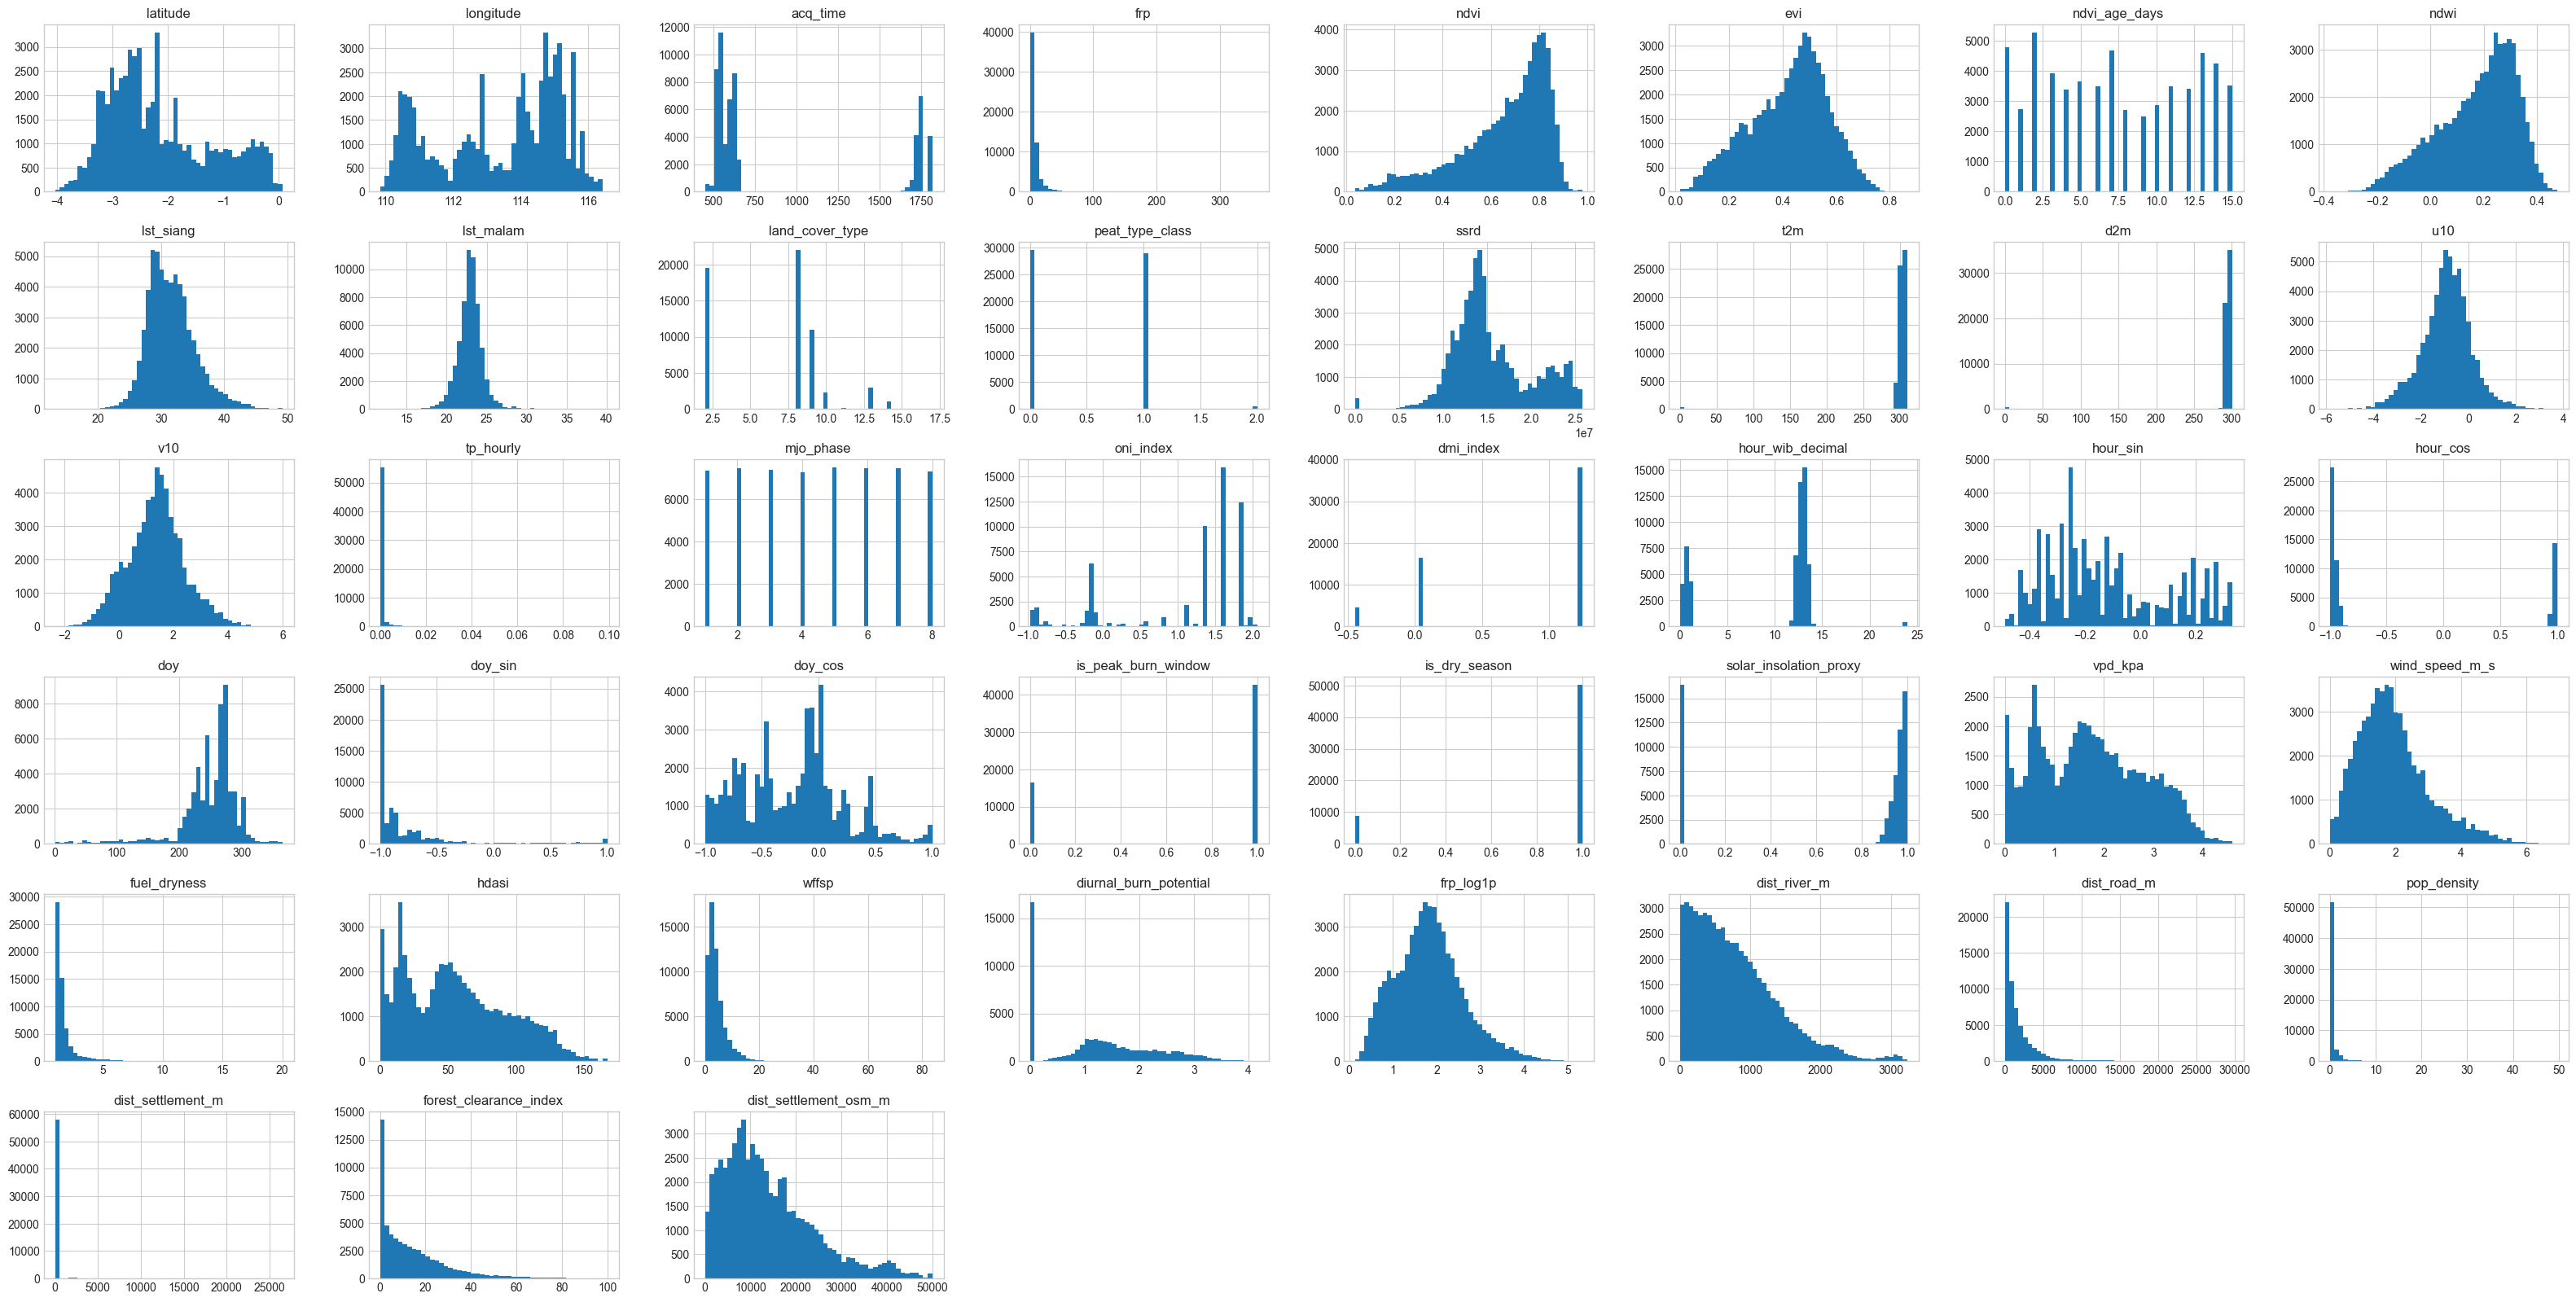

In [8]:
df.hist(bins=50, figsize=(40, 20), layout=(6,8))

In [17]:
corr_matrix = df.select_dtypes(include="number").corr()
corr_matrix["frp_log1p"].sort_values(ascending=False)

frp_log1p                 1.000000
frp                       0.796497
is_peak_burn_window       0.613423
solar_insolation_proxy    0.611997
hour_wib_decimal          0.576925
diurnal_burn_potential    0.473125
vpd_kpa                   0.453282
hdasi                     0.436849
latitude                  0.186085
ndvi                      0.183904
evi                       0.182273
ndwi                      0.177249
wind_speed_m_s            0.168066
v10                       0.154038
is_dry_season             0.103462
forest_clearance_index    0.089676
t2m                       0.070390
wffsp                     0.055315
doy                       0.024343
dist_settlement_osm_m     0.009893
mjo_phase                -0.006210
dist_road_m              -0.007349
dmi_index                -0.020110
d2m                      -0.025651
ndvi_age_days            -0.048669
oni_index                -0.061079
peat_type_class          -0.078043
doy_sin                  -0.089118
dist_river_m        

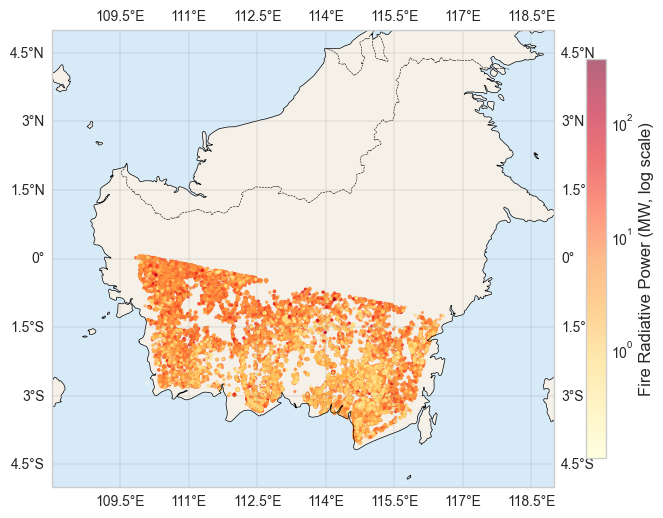

In [9]:
# --- Setup ---
fig, ax = plt.subplots(
    figsize=(7, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# --- Map background ---
ax.set_extent([108, 119, -5, 5], crs=ccrs.PlateCarree())  # Kalimantan bounding box
ax.add_feature(cfeature.LAND, facecolor='#f5f0e8')
ax.add_feature(cfeature.OCEAN, facecolor='#d6eaf8')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle='--')
ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)

# --- Scatter plot colored by FRP ---
sc = ax.scatter(
    df['longitude'],
    df['latitude'],
    c=df['frp'],                        # color by raw FRP
    cmap='YlOrRd',                      # yellow → orange → red
    norm=mcolors.LogNorm(),             # log scale (FRP is skewed!)
    s=2,                                # dot size
    alpha=0.6,
    transform=ccrs.PlateCarree(),
    rasterized=True
)

# --- Colorbar ---
cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.05)
cbar.set_label('Fire Radiative Power (MW, log scale)', fontsize=12)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}frp_map_kalimantan.pdf', bbox_inches='tight', dpi=300)
plt.show()

Numeric feature columns (35):
['latitude', 'longitude', 'acq_time', 'ndvi', 'evi', 'ndvi_age_days', 'ndwi', 'lst_siang', 'lst_malam', 'land_cover_type', 'peat_type_class', 'ssrd', 't2m', 'd2m', 'u10', 'v10', 'tp_hourly', 'mjo_phase', 'oni_index', 'dmi_index', 'hour_wib_decimal', 'hour_sin', 'hour_cos', 'doy', 'doy_sin', 'doy_cos', 'is_peak_burn_window', 'is_dry_season', 'solar_insolation_proxy', 'vpd_kpa', 'wind_speed_m_s', 'fuel_dryness', 'hdasi', 'wffsp', 'diurnal_burn_potential']

Non-numeric columns skipped:
['satellite', 'enso_phase']


KeyError: np.float64(nan)

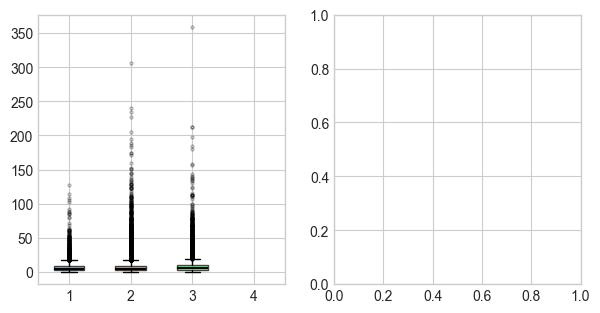

In [4]:
# --- Config ---
YEAR_COL = "acq_date"   # change if your date column has a different name
TARGET = "frp_log1p"
RAW_FRP = "frp"
COLS_TO_DROP = [YEAR_COL, RAW_FRP]  # exclude from feature grid; we'll plot them separately

# --- Prep ---
df["year"] = pd.to_datetime(df[YEAR_COL]).dt.year
numeric_cols = df.select_dtypes(include="number").columns.tolist()

# Separate target + raw FRP, then remaining features
feature_cols = [c for c in numeric_cols if c not in [TARGET, RAW_FRP, "year"]]

print(f"Numeric feature columns ({len(feature_cols)}):\n{feature_cols}")
print(f"\nNon-numeric columns skipped:\n{[c for c in df.columns if c not in numeric_cols and c != YEAR_COL]}")

years = sorted(df["year"].unique())
palette = {2022: "#4C9BE8", 2023: "#E8734C", 2024: "#4CE87A"}

def plot_boxplot_grid(cols, title_prefix, ncols=4):
    nrows = -(-len(cols) // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        data_by_year = [df[df["year"] == y][col].dropna() for y in years]
        bp = ax.boxplot(
            data_by_year,
            patch_artist=True,
            medianprops=dict(color="black", linewidth=1.5),
            flierprops=dict(marker="o", markersize=2, alpha=0.3),
            widths=0.5
        )
        for patch, year in zip(bp["boxes"], years):
            patch.set_facecolor(palette[year])
            patch.set_alpha(0.7)

        ax.set_title(col, fontsize=8, pad=4)
        ax.set_xticks(range(1, len(years) + 1))
        ax.set_xticklabels(years, fontsize=7)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.tick_params(axis="y", labelsize=7)

    # Hide unused subplots
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    handles = [plt.Rectangle((0,0),1,1, color=palette[y], alpha=0.7) for y in years]
    fig.legend(handles, [str(y) for y in years], title="Year",
               loc="lower right", fontsize=8, title_fontsize=8)

    fig.suptitle(title_prefix, fontsize=11, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

# --- Plot 1: Target + Raw FRP ---
plot_boxplot_grid([RAW_FRP, TARGET], "Target Variable — FRP & log1p(FRP)", ncols=2)

# --- Plot 2: All numeric features (split into chunks of 12) ---
chunk_size = 12
for i in range(0, len(feature_cols), chunk_size):
    chunk = feature_cols[i:i + chunk_size]
    plot_boxplot_grid(chunk, f"Features [{i+1}–{i+len(chunk)}]", ncols=4)

## Train-Test Split

The dataset has temporal attributes. It will be split into train and test set using the TimeSeries Cross-Validation approach to avoid data leakage, where we do training with future data and evaluating with past data since it doesn't make sense. Cross validation also helps capture

To ensure all splits are representative, each split contains training data starting from the first season and will be expanded by the next season in the next split. The testing data is from the season right after the last date of the training set.


In [11]:
drop_cols = [
    # Target and its raw version
    'frp', 'frp_log1p',

    # Non-numeric / identifier columns
    'acq_date', 'satellite', 'enso_phase',

    # Replaced by cyclical encodings
    'hour_wib_decimal', 'doy', 'acq_time',
]

# Cast to datetime and sort
df['acq_date'] = pd.to_datetime(df['acq_date'])
df = df.sort_values('acq_date').reset_index(drop=True)

# Re-apply X and y after sorting
X = df.drop(columns=drop_cols)
y = df['frp_log1p']

print(X.columns.tolist())
print(X.shape)

['latitude', 'longitude', 'ndvi', 'evi', 'ndvi_age_days', 'ndwi', 'lst_siang', 'lst_malam', 'land_cover_type', 'peat_type_class', 'ssrd', 't2m', 'd2m', 'u10', 'v10', 'tp_hourly', 'mjo_phase', 'oni_index', 'dmi_index', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'is_peak_burn_window', 'is_dry_season', 'solar_insolation_proxy', 'vpd_kpa', 'wind_speed_m_s', 'fuel_dryness', 'hdasi', 'wffsp', 'diurnal_burn_potential', 'dist_river_m', 'dist_road_m', 'pop_density', 'dist_settlement_m', 'forest_clearance_index', 'dist_settlement_osm_m']
(59155, 38)


In [19]:
import pandas as pd
from dateutil.relativedelta import relativedelta

def sliding_window_splits(df, datetime_col, train_months, test_months, step_months):
    """
    Generate sliding window train/test index pairs based on date ranges.

    Parameters
    ----------
    df : pd.DataFrame
        Must be sorted by datetime_col.
    datetime_col : str
        Name of the datetime column.
    train_months : int
        Size of the training window in months.
    test_months : int
        Size of the test window in months.
    step_months : int
        How far to slide the window forward each fold.

    Yields
    ------
    fold_num : int
    train_idx : pd.Index
    test_idx : pd.Index
    meta : dict  — start/end dates for inspection
    """
    df = df.sort_values(datetime_col).reset_index(drop=True)
    dates = pd.to_datetime(df[datetime_col])

    data_start = dates.min()
    data_end = dates.max()

    fold = 0
    train_start = data_start

    while True:
        train_end   = train_start + relativedelta(months=train_months)
        test_start  = train_end
        test_end    = test_start + relativedelta(months=test_months)

        if test_end > data_end:
            break

        train_mask = (dates >= train_start) & (dates < train_end)
        test_mask  = (dates >= test_start)  & (dates < test_end)

        train_idx = df.index[train_mask]
        test_idx  = df.index[test_mask]

        # Skip degenerate folds
        if len(train_idx) == 0 or len(test_idx) == 0:
            train_start += relativedelta(months=step_months)
            continue

        meta = {
            "train": (train_start.date(), train_end.date()),
            "test":  (test_start.date(),  test_end.date()),
        }

        yield fold, train_idx, test_idx, meta
        fold += 1
        train_start += relativedelta(months=step_months)


# --- Usage example ---
for fold, tr_idx, te_idx, meta in sliding_window_splits(
    df,
    datetime_col="acq_date",   # adjust to your column name
    train_months=12,
    test_months=3,
    step_months=3,
):
    print(f"Fold {fold} | Train: {meta['train']} ({len(tr_idx)} rows) | Test: {meta['test']} ({len(te_idx)} rows)")

Fold 0 | Train: (datetime.date(2022, 1, 1), datetime.date(2023, 1, 1)) (4485 rows) | Test: (datetime.date(2023, 1, 1), datetime.date(2023, 4, 1)) (399 rows)
Fold 1 | Train: (datetime.date(2022, 4, 1), datetime.date(2023, 4, 1)) (4494 rows) | Test: (datetime.date(2023, 4, 1), datetime.date(2023, 7, 1)) (1519 rows)
Fold 2 | Train: (datetime.date(2022, 7, 1), datetime.date(2023, 7, 1)) (5388 rows) | Test: (datetime.date(2023, 7, 1), datetime.date(2023, 10, 1)) (27894 rows)
Fold 3 | Train: (datetime.date(2022, 10, 1), datetime.date(2023, 10, 1)) (30453 rows) | Test: (datetime.date(2023, 10, 1), datetime.date(2024, 1, 1)) (13579 rows)
Fold 4 | Train: (datetime.date(2023, 1, 1), datetime.date(2024, 1, 1)) (43391 rows) | Test: (datetime.date(2024, 1, 1), datetime.date(2024, 4, 1)) (607 rows)
Fold 5 | Train: (datetime.date(2023, 4, 1), datetime.date(2024, 4, 1)) (43599 rows) | Test: (datetime.date(2024, 4, 1), datetime.date(2024, 7, 1)) (604 rows)
Fold 6 | Train: (datetime.date(2023, 7, 1), da

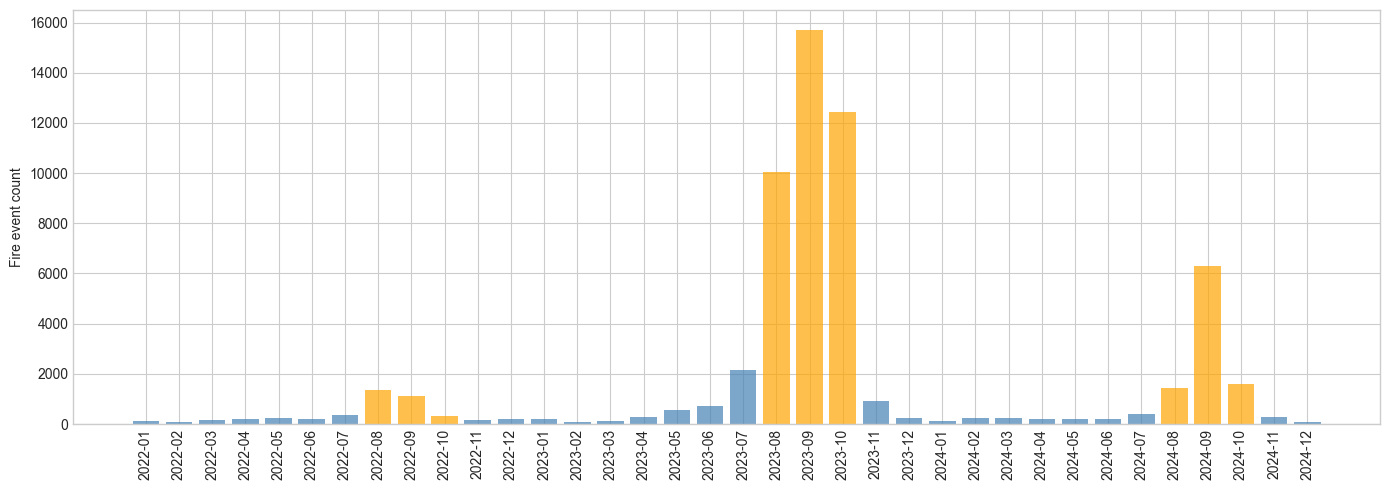

In [12]:
monthly = df.groupby(df['acq_date'].dt.to_period('M')).agg(
    count=('frp', 'count'),
    dry_season=('is_dry_season', 'max')  # 1 if any dry season in that month
).reset_index()

colors = ['orange' if d == 1 else 'steelblue' for d in monthly['dry_season']]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly['acq_date'].astype(str), monthly['count'], color=colors, alpha=0.7)
ax.set_ylabel('Fire event count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}fire_event_counts.pdf')
plt.show()

In [ ]:
splits = [
    ('2022-01-01', '2022-07-31', '2022-08-01', '2022-10-31'),  # test: dry 2022
    ('2022-01-01', '2022-10-31', '2022-11-01', '2023-07-31'),  # test: wet 2022-23
    ('2022-01-01', '2023-07-31', '2023-08-01', '2023-10-31'),  # test: dry 2023
    ('2022-01-01', '2023-10-31', '2023-11-01', '2024-07-31'),  # test: wet 2023-24
    ('2022-01-01', '2024-07-31', '2024-08-01', '2024-12-29'),  # test: dry 2024
]

### Manual split by season

- Time period is more meaningful
- Covers dry/wet season alternately
- Unbalanced data rows

In [ ]:
for i, (train_start, train_end, test_start, test_end) in enumerate(splits):
    train_idx = (df['acq_date'] >= train_start) & (df['acq_date'] <= train_end)
    test_idx  = (df['acq_date'] >= test_start) & (df['acq_date'] <= test_end)
    print(f"Fold {i+1}: Train={train_idx.sum()} | Test={test_idx.sum()} | Test: {test_start} to {test_end}")

### Sklearn TimeSeriesSplit by rows

- Data row counts are even
- Unbalanced time period

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    train_dates = df['acq_date'].iloc[train_idx]
    test_dates = df['acq_date'].iloc[test_idx]
    print(f"Fold {i+1}: Train={len(train_idx)} | Test={len(test_idx)} | Test: {test_dates.min().date()} to {test_dates.max().date()}")

In [ ]:
split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train: {X_train.shape} | {df['acq_date'].iloc[:split_idx].min().date()} to {df['acq_date'].iloc[:split_idx].max().date()}")
print(f"Test:  {X_test.shape}  | {df['acq_date'].iloc[split_idx:].min().date()} to {df['acq_date'].iloc[split_idx:].max().date()}")

In [ ]:
print("X_train NaN:", X_train.isnull().sum().sum())
print("X_test NaN:", X_test.isnull().sum().sum())
print("y_train NaN:", y_train.isnull().sum())
print("y_test NaN:", y_test.isnull().sum())

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")

In [ ]:
import numpy as np

# Baseline: what if we just predicted the mean every time?
y_mean_pred = np.full_like(y_test, y_train.mean())
rmse_baseline = root_mean_squared_error(y_test, y_mean_pred)
print(f"Naive baseline RMSE: {rmse_baseline:.4f}")
print(f"Random Forest RMSE:  {rmse:.4f}")

In [ ]:
# Convert back to original FRP scale to interpret error
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)
rmse_original = root_mean_squared_error(y_test_original, y_pred_original)
print(f"RMSE in original FRP units: {rmse_original:.2f} MW")
print(f"Mean FRP in test set: {y_test_original.mean():.2f} MW")
print(f"Median FRP in test set: {y_test_original.median():.2f} MW")

In [ ]:
# Look at where the large errors are
errors = np.abs(y_test_original - y_pred_original)
print(f"90th percentile error: {np.percentile(errors, 90):.2f} MW")
print(f"95th percentile error: {np.percentile(errors, 95):.2f} MW")
print(f"99th percentile error: {np.percentile(errors, 99):.2f} MW")
print(f"Max error: {errors.max():.2f} MW")

In [ ]:
df['acq_date'] = pd.to_datetime(df['acq_date'])

for i, (train_start, train_end, test_start, test_end) in enumerate(splits):
    train = df[(df['acq_date'] >= train_start) & (df['acq_date'] <= train_end)]
    test  = df[(df['acq_date'] >= test_start) & (df['acq_date'] <= test_end)]
    print(f"Fold {i+1}: Train={len(train)} rows | Test={len(test)} rows | Test: {test_start} to {test_end}")

In [ ]:
# Find coordinates that appear multiple times
coord_counts = df.groupby(['latitude', 'longitude']).size().sort_values(ascending=False)
print(coord_counts.head(10))

In [ ]:
# Take the most frequent coordinate
top_lat, top_lon = coord_counts.index[0]

# Filter and sort by date
df_coord = df[(df['latitude'] == top_lat) & (df['longitude'] == top_lon)]\
             .sort_values('acq_date')[['acq_date', 'acq_time', 'frp', 'frp_log1p']]

print(df_coord)

In [ ]:
tscv = TimeSeriesSplit()

for fold, (train_index, test_index) in enumerate(tscv.split(df_sorted_date)):
    print(f"Fold {fold+1}: Train {df_sorted_date['acq_date'].iloc[train_index].min()} to {df_sorted_date['acq_date'].iloc[train_index].max()}; Test {df_sorted_date['acq_date'].iloc[test_index].min()} to {df_sorted_date['acq_date'].iloc[test_index].max()}")

In [ ]:
print(df_sorted_date.groupby('is_dry_season')['acq_date'].agg(['min', 'max', 'count']))

In [ ]:
# See how fire events distribute across months
df_sorted_date['month'] = pd.to_datetime(df_sorted_date['acq_date']).dt.month
print(df_sorted_date.groupby('month')['frp'].agg(['count', 'mean']).round(2))

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define features and target
drop_cols = ['acq_date', 'satellite', 'enso_phase', 'frp', 'frp_log1p']
X = df.drop(columns=drop_cols)
y = df['frp_log1p']

# Single time-based split for now
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Train
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
# Create a mask where neither y_test nor y_pred is NaN
mask = ~np.isnan(y_test) & ~np.isnan(y_pred)

# Calculate RMSLE only on the valid entries
rmsle = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
print(f"RMSLE (valid entries only): {rmsle:.4f}")